<a href="https://colab.research.google.com/github/sneghaganesh3-rgb/Sign_text_converter/blob/main/Gesture_Control_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📦 Step 1 — Environment Setup & Dataset Download

In [ ]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q roboflow ultralytics seaborn matplotlib scikit-learn optuna pandas

import os, json, random, shutil, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import torch

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Check GPU
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 65.6 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# ── Download dataset from Roboflow ────────────────────────────────────────────
from roboflow import Roboflow

rf = Roboflow(api_key="IQy4PyB8Lbky9u7Xu3vY")
project = rf.workspace("imv2022").project("hand-gesture-pe0ge")
version  = project.version(2)
dataset  = version.download("yolov8")

DATASET_PATH = dataset.location
print(f"Dataset downloaded to: {DATASET_PATH}")

# Read data.yaml to confirm class names
import yaml
with open(os.path.join(DATASET_PATH, 'data.yaml')) as f:
    data_cfg = yaml.safe_load(f)
print("Classes:", data_cfg.get('names', []))
print("NC:", data_cfg.get('nc', 0))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hand-Gesture-2 in yolov8:: 100%|██████████| 8839/8839 [00:00<00:00, 9688.50it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/Hand-Gesture-2
Classes: ['ok', 'stop', 'thumb_down', 'thumb_up']
NC: 4


## 📊 Step 2 — Exploratory Data Analysis (EDA)

train      | Images:  3975 | Classes: {1: 1266, 3: 1495, 2: 1149, 0: 1257}
valid      | Images:   440 | Classes: {0: 136, 3: 164, 2: 133, 1: 154}
test       | Images:     0 | Classes: {}


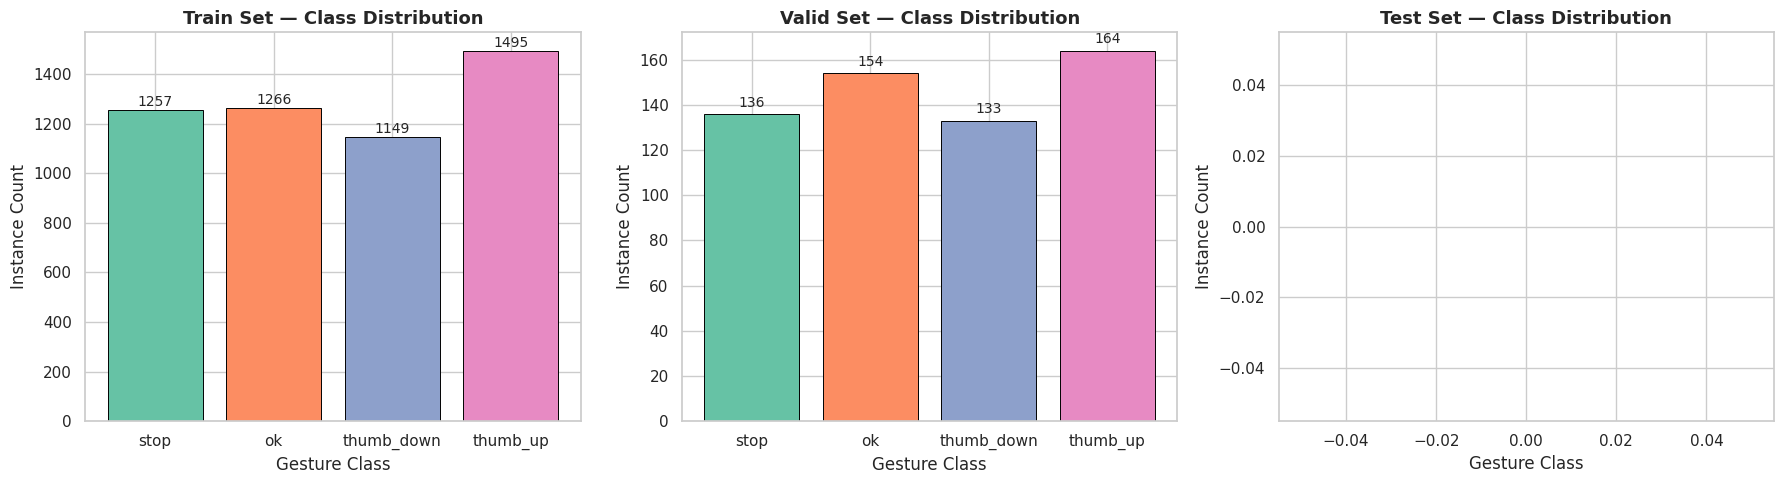

✅ EDA chart saved.


In [ ]:
# ── EDA: Count images and labels per split ────────────────────────────────────
CLASS_NAMES = ['stop', 'ok', 'thumb_down', 'thumb_up']  # adjust if yaml differs

def count_classes_in_split(label_dir, class_names):
    """Count bounding box instances per class in a label directory."""
    counts = Counter()
    label_dir = Path(label_dir)
    if not label_dir.exists():
        return counts
    for f in label_dir.glob('*.txt'):
        for line in f.read_text().splitlines():
            if line.strip():
                cls = int(line.split()[0])
                counts[cls] += 1
    return counts

splits = ['train', 'valid', 'test']
split_stats = {}

for split in splits:
    img_dir = Path(DATASET_PATH) / split / 'images'
    lbl_dir = Path(DATASET_PATH) / split / 'labels'
    n_images = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
    cls_counts = count_classes_in_split(lbl_dir, CLASS_NAMES)
    split_stats[split] = {'images': n_images, 'class_counts': cls_counts}
    print(f"{split:10s} | Images: {n_images:5d} | Classes: {dict(cls_counts)}")

# ── Bar chart: class distribution per split ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, split in zip(axes, splits):
    counts = split_stats[split]['class_counts']
    labels = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i) for i in sorted(counts)]
    values = [counts[i] for i in sorted(counts)]
    colors = sns.color_palette('Set2', len(labels))
    bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(f'{split.capitalize()} Set — Class Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Instance Count')
    ax.set_xlabel('Gesture Class')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()
print("✅ EDA chart saved.")

## ⚖️ Step 3 — Sampling Strategy (Handle Class Imbalance)

📊 Class Weights (inverse frequency):
  stop           : 1.0276
  ok             : 1.0203
  thumb_down     : 1.1242
  thumb_up       : 0.8640

⚠️  Imbalance ratio: 1.30x
→ Imbalance is acceptable. Standard training should work fine.


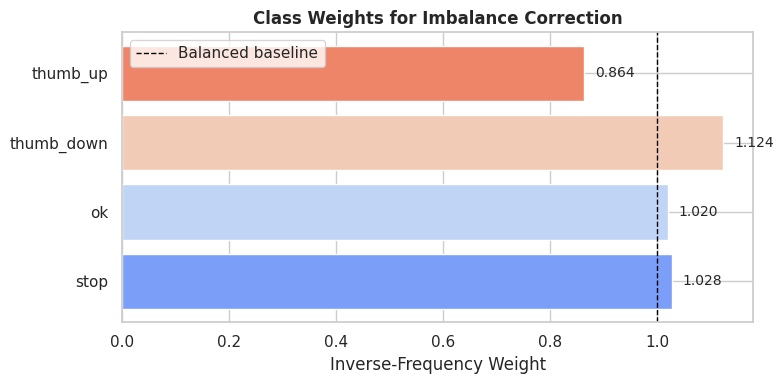

In [ ]:
# ── Compute class weights for imbalance-aware training ────────────────────────
train_counts = split_stats['train']['class_counts']
total = sum(train_counts.values())

if total > 0:
    # Inverse-frequency weighting
    class_weights = {}
    for cls_id in range(len(CLASS_NAMES)):
        count = train_counts.get(cls_id, 1)
        weight = total / (len(CLASS_NAMES) * count)
        class_weights[CLASS_NAMES[cls_id]] = round(weight, 4)

    print("📊 Class Weights (inverse frequency):")
    for name, w in class_weights.items():
        print(f"  {name:15s}: {w:.4f}")

    # Imbalance ratio
    max_cls = max(train_counts.values())
    min_cls = min(train_counts.values()) if train_counts else 1
    ratio = max_cls / min_cls
    print(f"\n⚠️  Imbalance ratio: {ratio:.2f}x")
    if ratio > 3:
        print("→ Imbalance is HIGH. Using class_weights + augmentation strategy.")
    else:
        print("→ Imbalance is acceptable. Standard training should work fine.")

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 4))
    names = list(class_weights.keys())
    weights = list(class_weights.values())
    bars = ax.barh(names, weights, color=sns.color_palette('coolwarm', len(names)))
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='Balanced baseline')
    ax.set_xlabel('Inverse-Frequency Weight')
    ax.set_title('Class Weights for Imbalance Correction', fontweight='bold')
    ax.legend()
    for bar, w in zip(bars, weights):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('class_weights.png', dpi=150)
    plt.show()
else:
    print("⚠️ No training labels found. Check dataset path.")

In [ ]:
# ── Oversampling minority classes via image copy augmentation ─────────────────
# Strategy: duplicate images of under-represented classes to balance the dataset

def oversample_minority_classes(dataset_path, class_names, target_ratio=0.8):
    """
    Duplicates images from minority classes until each class reaches
    (target_ratio × max_class_count) samples.
    """
    train_img_dir = Path(dataset_path) / 'train' / 'images'
    train_lbl_dir = Path(dataset_path) / 'train' / 'labels'

    # Map each image file to its classes
    img_to_classes = {}
    for lbl_file in train_lbl_dir.glob('*.txt'):
        classes_in_img = set()
        for line in lbl_file.read_text().splitlines():
            if line.strip():
                classes_in_img.add(int(line.split()[0]))
        img_name = lbl_file.stem
        img_to_classes[img_name] = classes_in_img

    # Count per class
    class_to_imgs = {i: [] for i in range(len(class_names))}
    for img_name, classes in img_to_classes.items():
        for cls in classes:
            if cls < len(class_names):
                class_to_imgs[cls].append(img_name)

    class_counts_orig = {cls: len(imgs) for cls, imgs in class_to_imgs.items()}
    max_count = max(class_counts_orig.values()) if class_counts_orig else 1
    target_count = int(max_count * target_ratio)

    print(f"Target count per class: {target_count}")
    print(f"Original counts: {class_counts_orig}")

    added = 0
    for cls_id, imgs in class_to_imgs.items():
        current = len(imgs)
        if current == 0 or current >= target_count:
            continue
        needed = target_count - current
        copies = random.choices(imgs, k=needed)
        for i, img_name in enumerate(copies):
            # Find image extension
            for ext in ['.jpg', '.jpeg', '.png']:
                src_img = train_img_dir / (img_name + ext)
                if src_img.exists():
                    dst_img = train_img_dir / f"{img_name}_aug{cls_id}_{i}{ext}"
                    dst_lbl = train_lbl_dir / f"{img_name}_aug{cls_id}_{i}.txt"
                    shutil.copy2(src_img, dst_img)
                    shutil.copy2(train_lbl_dir / (img_name + '.txt'), dst_lbl)
                    added += 1
                    break

    print(f"\n✅ Oversampling complete. Added {added} augmented images.")
    return added

# ── Decide whether to oversample ─────────────────────────────────────────────
APPLY_OVERSAMPLING = ratio > 2 if total > 0 else False
if APPLY_OVERSAMPLING:
    n_added = oversample_minority_classes(DATASET_PATH, CLASS_NAMES, target_ratio=0.75)
else:
    print("✅ Dataset is balanced — no oversampling needed.")

✅ Dataset is balanced — no oversampling needed.


## 🏋️ Step 4 — Model Training

In [ ]:
# ── Training configuration ────────────────────────────────────────────────────
from ultralytics import YOLO

DATA_YAML = os.path.join(DATASET_PATH, 'data.yaml')

# Common hyperparameters
COMMON_ARGS = dict(
    data      = DATA_YAML,
    epochs    = 30,
    imgsz     = 640,
    batch     = 16,
    patience  = 5,          # early stopping
    optimizer = 'AdamW',
    lr0       = 0.001,
    lrf       = 0.01,
    momentum  = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 3,

)

print("Training configuration ready ✅")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"Data YAML: {DATA_YAML}")

Training configuration ready ✅
Device: GPU
Data YAML: /content/Hand-Gesture-2/data.yaml


In [ ]:
# ── Train YOLOv8n (nano — fastest, lightest) ──────────────────────────────────
print("\n" + "="*60)
print("  Training YOLOv8n (Nano)")
print("="*60)

model_n = YOLO('yolov8n.pt')
results_n = model_n.train(
    **COMMON_ARGS,
    name='gesture_yolov8n',
)
print("\n✅ YOLOv8n training complete.")


  Training YOLOv8n (Nano)
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hand-Gesture-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gesture_yolov8n2, nbs=64, nms=False, opset=None, optimize=False, optimize

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 705.0±201.4 MB/s, size: 12.5 KB)
val: Scanning /content/Hand-Gesture-2/valid/labels.cache... 440 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 440/440 167.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 5.1it/s 5.5s
                   all        440        587      0.981      0.975      0.985      0.824
Speed: 1.9ms preprocess, 4.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
  EVALUATION — YOLOv8n
  Precision : 0.9814
  Recall    : 0.9751
  mAP50     : 0.9848
  mAP50-95  : 0.8242

Per-class summary:
  {'Class': 'ok', 'Images': np.int64(109), 'Instances': np.int64(136), 'Box-P': np.float64(0.97413), 'Box-R': np.float64(0.94853), 'Box-F1': np.flo

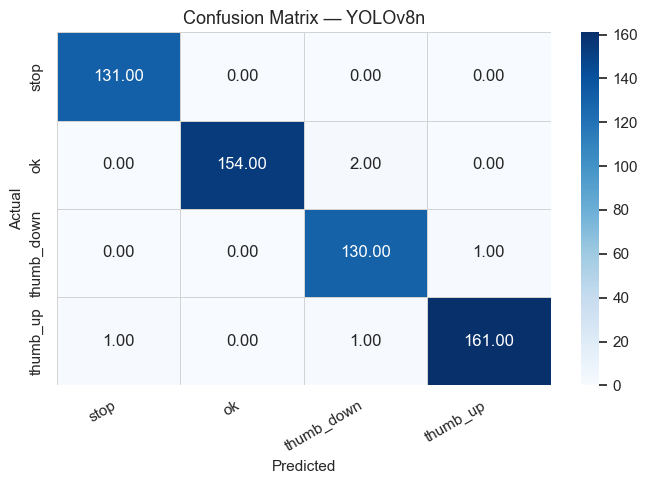

In [ ]:
BEST_PT = 'runs/detect/gesture_yolov8n2/weights/best.pt'
model_eval = YOLO(BEST_PT)
metrics    = model_eval.val(data=DATA_YAML, verbose=False)

precision, recall, mAP50, mAP50_95 = metrics.mean_results()

print('=' * 40)
print('  EVALUATION — YOLOv8n')
print('=' * 40)
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  mAP50     : {mAP50:.4f}')
print(f'  mAP50-95  : {mAP50_95:.4f}')
print()
print('Per-class summary:')
for row in metrics.summary():
    print(' ', row)

# Confusion matrix
cm = metrics.confusion_matrix.matrix
if cm is not None:
    n      = min(cm.shape[0], len(CLASS_NAMES))
    labels = CLASS_NAMES[:n]
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm[:n, :n], annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                linewidths=0.5, linecolor='lightgray')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)
    ax.set_title('Confusion Matrix — YOLOv8n', fontweight='bold', fontsize=13)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()

In [ ]:
# Training curves
csv_path = 'runs/detect/gesture_nano/results.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    epoch_col = 'epoch'

    for ax, train_col, val_col, title in [
        (axes[0], 'train/box_loss', 'val/box_loss', 'Box Loss'),
        (axes[1], 'train/cls_loss', 'val/cls_loss', 'Class Loss'),
        (axes[2], 'metrics/mAP50(B)', None,         'mAP50'),
    ]:
        if train_col in df.columns:
            ax.plot(df[epoch_col], df[train_col], label='Train', color='#7c5cfc', linewidth=2)
        if val_col and val_col in df.columns:
            ax.plot(df[epoch_col], df[val_col], label='Val', color='#00d4aa', linewidth=2)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        if val_col is None: ax.set_ylim(0, 1.05)
        ax.legend()

    plt.suptitle('Training Curves — YOLOv8n (30 epochs)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()
    print(' training_curves.png saved.')

In [ ]:
print('Exporting to ONNX...')
onnx_path = model_eval.export(format='onnx', dynamic=True, simplify=True)
pt_size   = os.path.getsize(BEST_PT) / 1e6
onnx_size = os.path.getsize(str(onnx_path)) / 1e6
print(f' PyTorch : {pt_size:.1f} MB  →  {BEST_PT}')
print(f' ONNX    : {onnx_size:.1f} MB  →  {onnx_path}')

Exporting to ONNX...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/gesture_yolov8n2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 257ms
Prepared 4 packages in 7.43s
Installed 4 packages in 458ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 8.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 11.8s, 

PyTorch FP32 : 8.5 ms ± 0.5
Loading runs/detect/gesture_yolov8n2/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
ONNX         : 10.1 ms ± 0.8


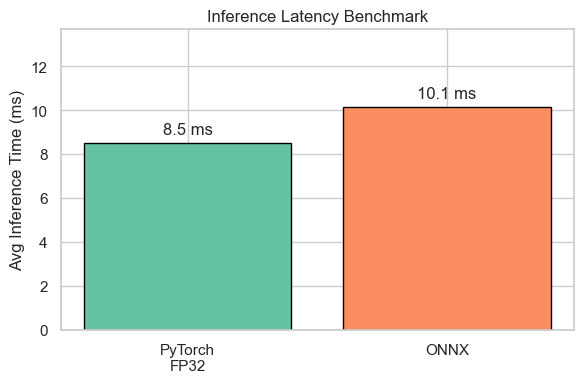

In [ ]:
dummy = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)
N_RUNS = 30

def benchmark(m):
    for _ in range(5): m(dummy, verbose=False)
    t = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        m(dummy, verbose=False)
        t.append((time.perf_counter() - t0) * 1000)
    return np.mean(t), np.std(t)

results_bench = {}

m_pt = YOLO(BEST_PT)
mu, sd = benchmark(m_pt)
results_bench['PyTorch\nFP32'] = mu
print(f'PyTorch FP32 : {mu:.1f} ms ± {sd:.1f}')

try:
    m_onnx = YOLO(str(onnx_path))
    mu2, sd2 = benchmark(m_onnx)
    results_bench['ONNX'] = mu2
    print(f'ONNX         : {mu2:.1f} ms ± {sd2:.1f}')
except Exception as e:
    print(f'ONNX benchmark skipped: {e}')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(list(results_bench.keys()), list(results_bench.values()),
              color=sns.color_palette('Set2', len(results_bench)), edgecolor='black')
for bar, v in zip(bars, results_bench.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f} ms', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Avg Inference Time (ms)')
ax.set_title('Inference Latency Benchmark', fontweight='bold')
ax.set_ylim(0, max(results_bench.values()) * 1.35)
plt.tight_layout()
plt.savefig('latency_benchmark.png', dpi=150)
plt.show()

In [ ]:
import zipfile

out = Path('gesture_outputs')
out.mkdir(exist_ok=True)

to_pack = [
    (BEST_PT,                    'best.pt'),
    (str(onnx_path),             'best.onnx'),
    ('eda_distribution.png',     'eda_distribution.png'),
    ('confusion_matrix.png',     'confusion_matrix.png'),
    ('training_curves.png',      'training_curves.png'),
    ('latency_benchmark.png',    'latency_benchmark.png'),
]

for src, dst in to_pack:
    if os.path.exists(src):
        shutil.copy2(src, out / dst)
        print(f'  {dst}')
    else:
        print(f'  (not found) {src}')

zip_name = 'gesture_model.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in out.iterdir():
        zf.write(f, f.name)

print(f'\n gesture_model.zip  ({os.path.getsize(zip_name)/1e6:.1f} MB)')

try:
    from google.colab import files
    files.download(zip_name)
    print('Download started!')
except ImportError:
    print(f'Find it at: {os.path.abspath(zip_name)}')

  best.pt
  best.onnx
  (not found) eda_distribution.png
  confusion_matrix.png
  (not found) training_curves.png
  latency_benchmark.png

 gesture_model.zip  (16.3 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
